In [1]:
### First read both revcomp and forward var effects
import pandas as pd

forward = pd.read_csv("/scratch/st-cdeboer-1/sambina/position_mpra/outputs/2-opentargets_model_variant_effect/gosai/k562_gosai_1bp.csv.gz", compression="gzip")
reverse = pd.read_csv("/scratch/st-cdeboer-1/sambina/position_mpra/outputs/2-opentargets_model_variant_effect/gosai/k562_gosai_revcomp_1bp.csv.gz", compression="gzip")

# print(forward.head(1))

### Have to switch the column labels for the forward df
rename_dict = {}
for col in forward.columns:
    if col.startswith("offset_"):
        pos = int(col.split("_")[1])
        flipped_col = f"offset_{-pos}"
        rename_dict[col] = flipped_col

# Apply the renaming
forward = forward.rename(columns=rename_dict)
# print(forward.head(1))

In [2]:
### Now change the values
offset_cols = [col for col in forward.columns if col.startswith("offset_")]
forward[offset_cols] = forward[offset_cols].applymap(lambda x: float(x.strip("[]")) if isinstance(x, str) else x)
forward["seq_id"] = ["seq_" + str(i + 1) for i in range(len(forward))]

reverse[offset_cols] = reverse[offset_cols].applymap(lambda x: float(x.strip("[]")) if isinstance(x, str) else x)
reverse["seq_id"] = ["seq_rev_" + str(i + 1) for i in range(len(reverse))]

/tmp/ipykernel_3429032/2042737668.py:3: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  forward[offset_cols] = forward[offset_cols].applymap(lambda x: float(x.strip("[]")) if isinstance(x, str) else x)
/tmp/ipykernel_3429032/2042737668.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  forward["seq_id"] = ["seq_" + str(i + 1) for i in range(len(forward))]
/tmp/ipykernel_3429032/2042737668.py:6: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  reverse[offset_cols] = reverse[offset_cols].applymap(lambda x: float(x.strip("[]")) if isinstance(x, str) else x)
/tmp/ipykernel_3429032/2042737668.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `fr

In [3]:
### Combine and filter out the rows
forward["strand"] = "forward"
reverse["strand"] = "reverse"
combined = pd.concat([forward, reverse], ignore_index=True)
offset_cols = [col for col in combined.columns if col.startswith("offset_")]
# filtered = combined[combined[offset_cols].apply(
#     lambda row: (row > 0.5).any() or (row < -0.5).any(), axis=1)]
filtered = combined

print(len(filtered))

/tmp/ipykernel_3429032/3291086465.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  forward["strand"] = "forward"
/tmp/ipykernel_3429032/3291086465.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  reverse["strand"] = "reverse"


206706


In [4]:
filtered.head()

,offset_90,offset_89,offset_88,offset_87,offset_86,offset_85,offset_84,offset_83,offset_82,offset_81,...,offset_-83,offset_-84,offset_-85,offset_-86,offset_-87,offset_-88,offset_-89,offset_-90,seq_id,strand
0,-0.018176,-0.059843,-0.031143,-0.012529,-0.029059,-0.038252,-0.020363,-0.017464,-0.019834,-0.017567,...,-0.050125,-0.050158,-0.058488,-0.027965,-0.033694,-0.031354,-0.048023,-0.008898,seq_1,forward
1,-0.232132,-0.126207,-0.118460,-0.041470,-0.175483,-0.213302,-0.575925,-0.568271,-0.191388,-0.318823,...,-0.084919,-0.046541,-0.067918,-0.055241,-0.088790,-0.087490,-0.120689,-0.107643,seq_2,forward
2,-0.002799,0.009346,-0.036531,0.003831,-0.012440,-0.007057,0.021231,0.082029,0.028715,0.044438,...,0.036617,0.034319,0.011682,-0.014072,-0.003404,-0.002118,0.017440,-0.108728,seq_3,forward
3,0.123727,0.120877,0.115691,0.045008,0.128721,0.121758,0.157327,0.141717,0.126562,0.121629,...,0.078932,0.068659,0.054189,0.116903,0.056635,0.050870,0.052557,0.060780,seq_4,forward
4,0.635050,1.439442,1.476804,1.493495,1.690242,1.520208,1.332401,1.045798,0.932848,0.790957,...,0.839936,0.823703,0.991028,0.817270,0.664880,0.348981,0.705748,0.757836,seq_5,forward


### Count how many variants are there at any position

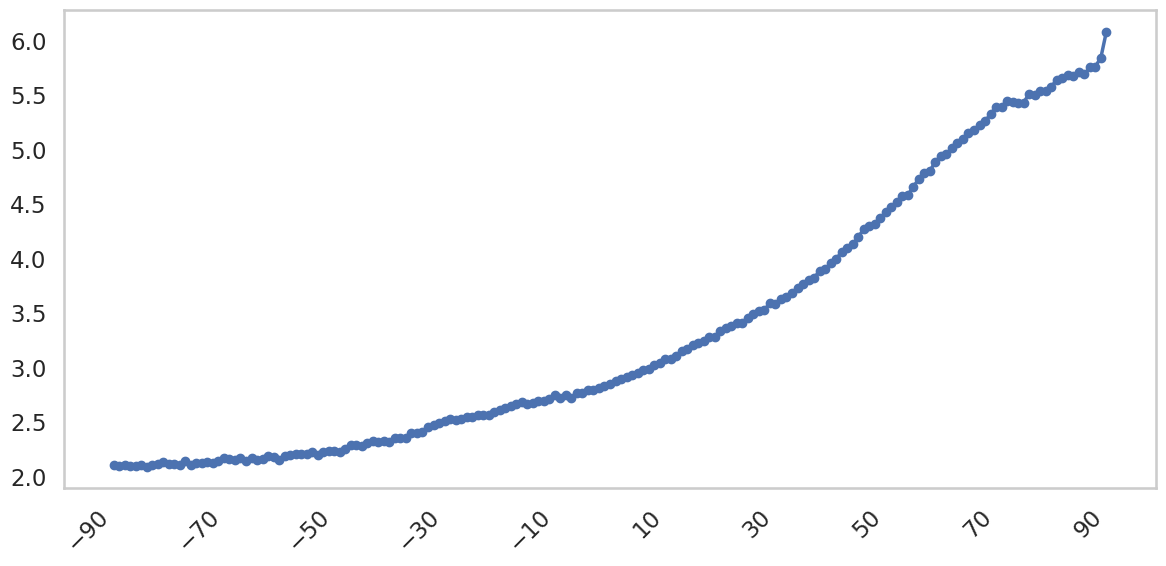

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

# Get the offset columns (those like "offset_90", "offset_-90", etc.)
offset_cols = [col for col in filtered.columns if col.startswith("offset_")]
heatmap_data = filtered[offset_cols]

# Extract numeric positions from column names (e.g. "offset_-90" -> -90)
positions = [int(col.split("_")[1]) for col in offset_cols]

# Count rows with value > 0.5 or < -0.5 at each column
counts = ((heatmap_data > 0.5) | (heatmap_data < -0.5)).sum(axis=0).values

# Convert to percentage of total variants
total_variants = heatmap_data.shape[0]
percentages = counts / total_variants * 100

# Build dataframe for plotting
percent_df = pd.DataFrame({
    "position": positions,
    "percent": percentages
}).sort_values("position")

import matplotlib.pyplot as plt
import seaborn as sns

# Use seaborn style for nicer aesthetics
sns.set(style="whitegrid", context="talk")

plt.figure(figsize=(12,6))

# Line with thicker width and larger markers
plt.plot(
    percent_df["position"], 
    percent_df["percent"], 
    marker="o", 
    markersize=6, 
    linewidth=2.5, 
    color="#4C72B0" 
)

# Set ticks every 20 positions
tick_positions = list(range(-90, 91, 20))
plt.xticks(tick_positions, rotation=45, ha='right')


plt.grid(True, linestyle="--", alpha=0)

plt.tight_layout()

plt.savefig(
    "/scratch/st-cdeboer-1/sambina/position_mpra/outputs/3-cluster/percentage_variants_all.svg",
    format="svg"
)
plt.show()


In [6]:
filtered[offset_cols] = filtered[offset_cols].apply(lambda row: row / row.loc[row.abs().idxmax()], axis=1)
filtered.head(2)

,offset_90,offset_89,offset_88,offset_87,offset_86,offset_85,offset_84,offset_83,offset_82,offset_81,...,offset_-83,offset_-84,offset_-85,offset_-86,offset_-87,offset_-88,offset_-89,offset_-90,seq_id,strand
0,0.103188,0.339732,0.176804,0.071127,0.164968,0.217161,0.115601,0.099145,0.112602,0.099729,...,0.284561,0.284754,0.332042,0.158759,0.191282,0.178002,0.272633,0.050514,seq_1,forward
1,0.403059,0.219138,0.205686,0.072006,0.304698,0.370364,1.000000,0.986710,0.332315,0.553584,...,0.147449,0.080811,0.117929,0.095917,0.154170,0.151912,0.209558,0.186904,seq_2,forward


In [7]:
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap


# new_offset_cols = sorted(renamed_cols.values(), key=lambda x: int(x.split('_')[1]))
new_offset_cols = sorted(offset_cols, key=lambda x: int(x.split('_')[1]))

heatmap_data = filtered[new_offset_cols]
heatmap_data.index = filtered['seq_id']  

colors = ['#3361A5', '#ffffff', '#A52126']

cmap = LinearSegmentedColormap.from_list('custom_red_black_blue', colors, N=256)

In [8]:
### check how many rows here have a sign change 
import pandas as pd

# Boolean mask: row has at least one >0 and at least one <0
mask = (heatmap_data.gt(0).any(axis=1)) & (heatmap_data.lt(0).any(axis=1))

# Count how many rows have both + and -
num_sign_change = mask.sum()

# Total number of rows (variants)
total_rows = len(heatmap_data)

# Percentage
percent_sign_change = (num_sign_change / total_rows) * 100

print(f"Rows with sign change: {num_sign_change}/{total_rows} ({percent_sign_change:.2f}%)")



Rows with sign change: 160607/206706 (77.70%)


In [9]:

### Plot the heatmap

g = sns.clustermap(
    heatmap_data,    
    cmap=cmap,
    metric='euclidean', 
    method='complete',
    figsize=(10,20),
    annot=False,           
    col_cluster=False,    
    z_score=None,
    standard_scale=None,
    vmin=-1,
    vmax=1
)

g.cax.set_position([0, .3, .02, .4])
g.cax.set_ylabel("scaled predicted variant effect", rotation=90, labelpad=12)
g.cax.set_visible(False)

positions = list(range(-90, 91, 20))  # -90, -80, ..., 80, 90
tick_positions = [pos + 90 for pos in positions]  # shift positions to 0-based indices

g.ax_heatmap.set_xticks(tick_positions)
g.ax_heatmap.set_xticklabels(positions, rotation=45, ha='right', fontsize=18)
g.ax_heatmap.set_xlabel("Position (wrt centre)")
g.ax_heatmap.set_ylabel("seq_id")
g.fig.suptitle("Clustered heatmap for OpenTarget variants", y=1.001, fontsize=16, ha='center')
plt.savefig(
    "/scratch/st-cdeboer-1/sambina/position_mpra/outputs/cluster/heatmap_OT_all.png",
    dpi=300,               
    bbox_inches="tight"
)
plt.show()


/arc/project/st-cdeboer-1/sambina/miniconda3/envs/dream_rocky/lib/python3.10/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


: 

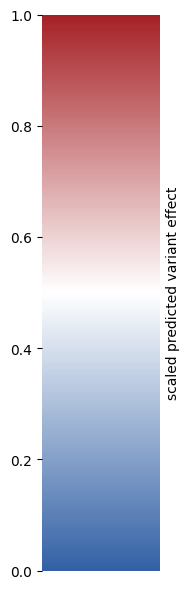

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, Normalize
from matplotlib.colorbar import ColorbarBase

colors = ['#3361A5', '#ffffff', '#A52126']
cmap = LinearSegmentedColormap.from_list('custom_red_black_blue', colors, N=256)

fig, ax = plt.subplots(figsize=(2, 6))  # Tall, narrow for colorbar
norm = Normalize(vmin=0, vmax=1)         # Match heatmap scale

cb = ColorbarBase(ax, cmap=cmap, norm=norm, orientation='vertical')
cb.set_label("scaled predicted variant effect")

# Remove border and ticks
for spine in ax.spines.values():
    spine.set_visible(False)

ax.tick_params(left=False, right=False, labelleft=True)  # Keep labels, remove ticks
ax.yaxis.set_ticks_position('left')                      # Keep ticks on left side only if you want labels

plt.tight_layout()

# Save the colorbar as SVG and PNG
cb_path_svg = "/scratch/st-cdeboer-1/sambina/position_mpra/outputs/cluster/colorbar.svg"
cb_path_png = "/scratch/st-cdeboer-1/sambina/position_mpra/outputs/cluster/colorbar.png"

fig.savefig(cb_path_svg, dpi=300, bbox_inches='tight', transparent=True)
fig.savefig(cb_path_png, dpi=300, bbox_inches='tight', transparent=True)

plt.show()

